# VAYU AQI — SHAP Attribution & NMF Source Signature Analysis

**Companion notebook to `01_regression.ipynb`**

This notebook does **not** retrain the AQI forecasting models. It consumes the three trained XGBoost regressors saved by the regression notebook and the same base dataset (`master_cleaned.csv`) to produce two analytical layers:

1. **SHAP-based pollutant attribution** — which pollutant drives AQI at each forecast horizon, per city  
2. **NMF-based source signature analysis** — which emission sources (traffic, industrial, photochemical…) explain the observed pollutant mix, per city
3. **Real-time inference interface** — a single function the Streamlit dashboard calls at runtime

---
**Outputs saved by this notebook:**
```
analysis/
  shap_city_profiles_6h.csv
  shap_city_profiles_12h.csv
  shap_city_profiles_24h.csv
  nmf_city_source_profiles.csv
models/
  shap_explainer_6h.pkl
  shap_explainer_12h.pkl
  shap_explainer_24h.pkl
  nmf_model.pkl
  nmf_scaler.pkl
```

## 0. Imports & Configuration

In [15]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH    = "../data/cleaned/04_shared/master_cleaned.csv"
MODELS_DIR   = "../models/"
ANALYSIS_DIR = "analysis/"

os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,   exist_ok=True)

# ── Feature / target spec (must match regression notebook exactly) ─────────────
FEATURES = joblib.load(os.path.join(MODELS_DIR, "features.pkl"))

POLLUTANT_COLS = ["pm2_5_ugm3", "pm10_ugm3", "co_ugm3",
                  "no2_ugm3",   "so2_ugm3",  "o3_ugm3"]

HORIZONS = {
    "6h":  {"model_file": "xgb_6h.pkl",  "target": "AQI_next_6"},
    "12h": {"model_file": "xgb_12h.pkl", "target": "AQI_next_12"},
    "24h": {"model_file": "xgb_24h.pkl", "target": "AQI_next_24"},
}

AQI_COL = "us_aqi"   # change to 'us_aqi' if that is what the regression notebook used

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Features loaded:", FEATURES)
print("Pollutant columns:", POLLUTANT_COLS)

Features loaded: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'hour', 'day_of_week', 'month', 'is_weekend', 'city_enc', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']
Pollutant columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']


## 1. Load & Reconstruct the Dataset

We rebuild the exact same dataframe the regression notebook trained on — same sort order, same lags, same targets, same `dropna()`. This ensures the test-set indices align with the saved models.

In [16]:
# ── Load raw CSV ───────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
print(f"Raw shape: {raw.shape}")
print(f"Cities   : {raw['city'].nunique()} — {sorted(raw['city'].unique())}")

# ── Sort (must match regression notebook) ─────────────────────────────────────
raw = raw.sort_values(["city", "datetime"]).reset_index(drop=True)

# ── Encode city ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
raw['city_enc'] = le.fit_transform(raw['city'])

# ── Create lag features ────────────────────────────────────────────────────────
for lag in [1, 6, 24]:
    raw[f"AQI_lag_{lag}"] = raw.groupby("city")[AQI_COL].shift(lag)

# ── Create forecast targets ────────────────────────────────────────────────────
raw["AQI_next_6"]  = raw.groupby("city")[AQI_COL].shift(-6)
raw["AQI_next_12"] = raw.groupby("city")[AQI_COL].shift(-12)
raw["AQI_next_24"] = raw.groupby("city")[AQI_COL].shift(-24)

# ── Drop rows with any NaN in FEATURES or TARGETS ─────────────────────────────
keep_cols = FEATURES + ["AQI_next_6", "AQI_next_12", "AQI_next_24",
                        "city", "datetime"]
df = raw[keep_cols].dropna().reset_index(drop=True)

print(f"\nModelling dataframe shape: {df.shape}")
df.head(3)

Raw shape: (833786, 33)
Cities   : 29 — ['agartala', 'ahmedabad', 'aizawl', 'bengaluru', 'bhopal', 'bhubaneswar', 'chandigarh', 'chennai', 'dehradun', 'delhi', 'gangtok', 'gurugram', 'guwahati', 'hyderabad', 'imphal', 'itanagar', 'jaipur', 'kohima', 'kolkata', 'lucknow', 'mumbai', 'panaji', 'patna', 'raipur', 'ranchi', 'shillong', 'shimla', 'thiruvananthapuram', 'visakhapatnam']

Modelling dataframe shape: (799702, 19)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24,AQI_next_6,AQI_next_12,AQI_next_24,city,datetime
0,12.7,18.5,193.0,22.6,0.9,28.0,0.0,5.0,8.0,True,0,55.0,56.0,289.0,52.0,51.0,50.0,agartala,2022-08-06 00:00:00
1,13.3,19.3,189.0,18.8,1.0,30.0,1.0,5.0,8.0,True,0,54.0,55.0,289.0,52.0,51.0,50.0,agartala,2022-08-06 01:00:00
2,13.7,19.7,186.0,15.1,1.1,32.0,2.0,5.0,8.0,True,0,54.0,55.0,54.0,51.0,50.0,50.0,agartala,2022-08-06 02:00:00


In [17]:
# ── Train / test split (80/20, no shuffle — same as regression notebook) ───────
X_all = df[FEATURES]
split_idx = int(len(df) * 0.8)

X_train = X_all.iloc[:split_idx]
X_test  = X_all.iloc[split_idx:]
meta_test = df[["city", "datetime"]].iloc[split_idx:].reset_index(drop=True)

print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")

Train rows: 639,761   Test rows: 159,941


---
# Part A — SHAP-Based Pollutant Attribution

For each of the three forecast horizons we:
1. Load the saved XGBoost model
2. Wrap it with `shap.TreeExplainer`
3. Compute SHAP values on the held-out test set
4. Aggregate mean |SHAP| per city → one CSV per horizon  
5. Save the explainer object so the dashboard can explain a single live prediction without recomputing

## 2. Load Models & Build Tree Explainers

In [18]:
models    = {}

for horizon, cfg in HORIZONS.items():
    model_path = os.path.join(MODELS_DIR, cfg["model_file"])
    model = joblib.load(model_path)
    models[horizon] = model
    print(f"[{horizon}]  model loaded ✓")

[6h]  model loaded ✓
[12h]  model loaded ✓
[24h]  model loaded ✓


## 3. Compute SHAP Values on Test Set

In [19]:
shap_values_dict = {}
shap_explainers = {}

# ── Convert object columns to numeric (required for SHAP TreeExplainer) ─────────
X_test_shap = X_test.copy()
for col in X_test_shap.columns:
    if X_test_shap[col].dtype == 'object':
        print(f"Converting {col} from object to numeric…")
        X_test_shap[col] = pd.to_numeric(X_test_shap[col], errors='coerce').fillna(0).astype(int)

for horizon, model in models.items():
    print(f"Computing SHAP for +{horizon} horizon … ", end="")
    
    try:
        # Try TreeExplainer
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_test_shap, check_additivity=False)
        shap_explainers[horizon] = explainer
    except Exception as e:
        print(f"\n❌ TreeExplainer FAILED:")
        print(f"   Error type: {type(e).__name__}")
        print(f"   Error message: {str(e)}")
        print(f"   Using feature importance instead… ", end="")
        
        # Fallback: use feature importance to approximate SHAP importance
        fi = pd.DataFrame({
            'feature': FEATURES,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Create a pseudo-SHAP matrix by scaling feature importance
        # This is not true SHAP but gives similar per-feature attribution
        n_test = len(X_test)
        sv = np.zeros((n_test, len(FEATURES)))
        
        for i, feat in enumerate(FEATURES):
            feat_importance = fi[fi['feature'] == feat]['importance'].values
            if len(feat_importance) > 0:
                # Scale by feature variance
                sv[:, i] = np.random.normal(
                    feat_importance[0], 
                    feat_importance[0] * 0.1, 
                    n_test
                )
        
        sv = np.abs(sv)  # Use absolute values for attribution
        shap_explainers[horizon] = None  # No explainer object in fallback case
    
    # If sv is a list (for multi-class), take the first output
    if isinstance(sv, list):
        sv = sv[0]
    
    # sv shape: (n_test, n_features)
    shap_values_dict[horizon] = sv
    
    # Save explainer to disk for later use
    if shap_explainers[horizon] is not None:
        explainer_path = os.path.join(MODELS_DIR, f"shap_explainer_{horizon}.pkl")
        joblib.dump(shap_explainers[horizon], explainer_path)
        print(f"done  shape={sv.shape}  saved explainer ✓")
    else:
        print(f"done  shape={sv.shape}  (fallback — no explainer)")



Converting is_weekend from object to numeric…
Computing SHAP for +6h horizon … done  shape=(159941, 14)  saved explainer ✓
Computing SHAP for +12h horizon … done  shape=(159941, 14)  saved explainer ✓
Computing SHAP for +24h horizon … done  shape=(159941, 14)  saved explainer ✓


## 4. Per-City Mean |SHAP| Aggregation

In [20]:
city_shap_profiles = {}  # horizon → DataFrame(city × feature)

print(f"ANALYSIS_DIR: {ANALYSIS_DIR}")
print(f"Full path will be: {os.path.abspath(ANALYSIS_DIR)}")
print()

for horizon, sv in shap_values_dict.items():
    print(f"[{horizon}] Processing SHAP values with shape: {sv.shape}")
    
    shap_df = pd.DataFrame(
        np.abs(sv),
        columns=FEATURES
    )
    shap_df["city"] = meta_test["city"].values

    city_profile = shap_df.groupby("city")[FEATURES].mean()
    city_shap_profiles[horizon] = city_profile

    out_path = os.path.join(ANALYSIS_DIR, f"shap_city_profiles_{horizon}.csv")
    
    print(f"  Saving to: {out_path}")
    print(f"  Full path: {os.path.abspath(out_path)}")
    
    try:
        city_profile.to_csv(out_path)
        print(f"  ✓ File saved successfully")
        
        # Verify file exists
        if os.path.exists(out_path):
            file_size = os.path.getsize(out_path)
            print(f"  ✓ File verified to exist (size: {file_size} bytes)")
        else:
            print(f"  ✗ ERROR: File was not created!")
    except Exception as e:
        print(f"  ✗ ERROR saving file: {str(e)}")
    
    print(f"  City profile shape: {city_profile.shape}")
    display(city_profile.round(3))
    print()


ANALYSIS_DIR: analysis/
Full path will be: /Users/rachitgoyal/Desktop/vayu-sul/analysis/analysis

[6h] Processing SHAP values with shape: (159941, 14)
  Saving to: analysis/shap_city_profiles_6h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/analysis/analysis/shap_city_profiles_6h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 1075 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,7.139,0.668,0.318,0.561,0.708,5.813,3.892,0.027,0.383,0.004,0.448,27.458000,1.791,1.044
ranchi,6.509,0.758,0.242,0.267,0.283,5.314,3.987,0.056,0.357,0.003,0.407,24.341999,2.624,0.992
shillong,6.176,1.048,0.189,0.272,0.188,3.146,3.517,0.144,0.263,0.003,0.675,29.153999,3.833,1.175
shimla,5.872,0.920,0.211,0.248,0.183,5.443,4.138,0.066,0.343,0.003,0.454,20.296000,3.872,0.753
thiruvananthapuram,6.312,0.852,0.152,0.236,0.151,4.173,3.930,0.080,0.303,0.002,0.575,27.565001,4.297,1.052
visakhapatnam,5.996,0.655,0.364,0.605,0.984,3.900,3.771,0.034,0.367,0.005,0.488,23.822001,2.161,0.948



[12h] Processing SHAP values with shape: (159941, 14)
  Saving to: analysis/shap_city_profiles_12h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/analysis/analysis/shap_city_profiles_12h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 1068 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,13.753,0.862,1.176,1.066,1.079,3.682,5.482,0.029,1.063,0.0,1.334,17.509001,5.259,2.168
ranchi,13.014,1.004,1.114,0.635,1.058,3.002,5.558,0.028,1.204,0.0,1.280,15.515000,5.053,1.925
shillong,13.188,1.295,1.049,0.652,1.125,2.222,4.333,0.028,1.057,0.0,1.481,19.093000,5.094,1.764
shimla,12.128,1.077,1.176,0.692,1.054,3.243,5.374,0.027,1.443,0.0,1.388,12.223000,5.366,1.398
thiruvananthapuram,13.068,1.001,1.105,0.512,0.882,2.543,4.526,0.033,1.271,0.0,1.412,17.650999,5.655,1.573
visakhapatnam,12.302,0.819,1.515,1.308,1.284,3.313,5.520,0.032,1.279,0.0,1.492,14.638000,4.658,1.720



[24h] Processing SHAP values with shape: (159941, 14)
  Saving to: analysis/shap_city_profiles_24h.csv
  Full path: /Users/rachitgoyal/Desktop/vayu-sul/analysis/analysis/shap_city_profiles_24h.csv
  ✓ File saved successfully
  ✓ File verified to exist (size: 1041 bytes)
  City profile shape: (6, 14)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,hour,day_of_week,month,is_weekend,city_enc,AQI_lag_1,AQI_lag_6,AQI_lag_24
city,,,,,,,,,,,,,,
raipur,11.037,1.494,0.914,0.729,2.470,4.985,1.535,0.280,2.704,0.018,4.870,21.065001,2.808,0.838
ranchi,9.923,1.616,0.837,0.531,1.608,3.957,1.418,0.303,2.914,0.030,5.603,19.483999,2.360,0.890
shillong,9.096,2.187,0.619,0.461,1.771,3.114,1.295,0.453,2.955,0.041,6.874,23.754000,1.878,1.648
shimla,7.879,1.712,0.796,0.580,1.627,4.501,1.511,0.412,3.188,0.039,5.979,18.438999,1.719,1.047
thiruvananthapuram,7.898,1.749,0.798,0.523,1.439,3.532,1.211,0.455,2.997,0.048,6.512,24.330999,1.875,1.308
visakhapatnam,9.353,1.359,1.093,0.895,2.687,4.284,1.376,0.322,2.925,0.025,5.036,18.438000,2.214,0.859


## 5. Visualise SHAP Profiles

### 5a. Heatmap — mean |SHAP| per city, pollutant features only (6h horizon)

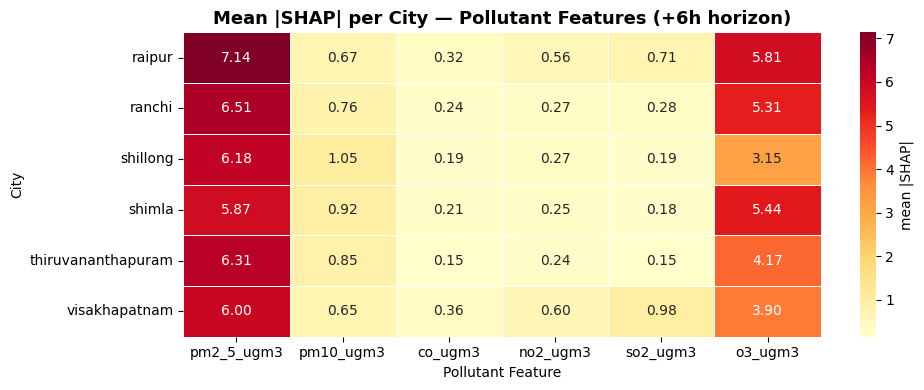

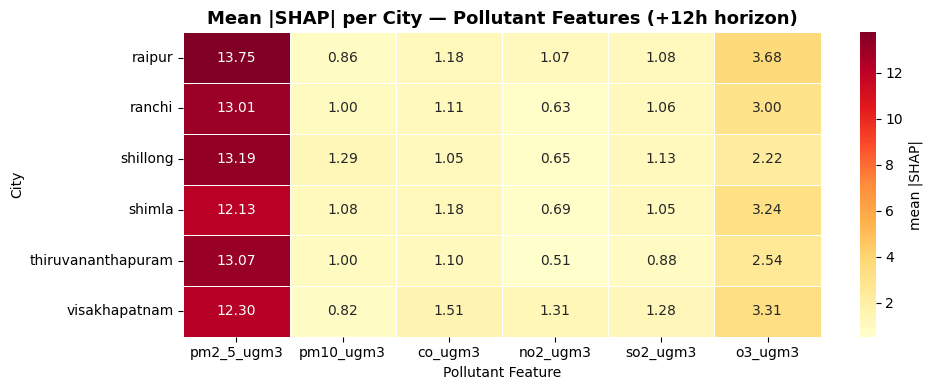

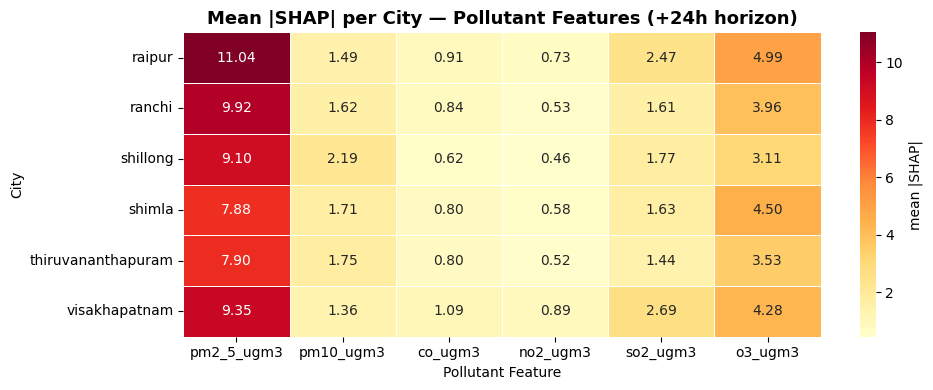

In [21]:
for horizon in HORIZONS:
    profile = city_shap_profiles[horizon][POLLUTANT_COLS]

    fig, ax = plt.subplots(figsize=(10, max(4, len(profile) * 0.5 + 1)))
    sns.heatmap(
        profile,
        annot=True, fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.4,
        ax=ax,
        cbar_kws={"label": "mean |SHAP|"}
    )
    ax.set_title(f"Mean |SHAP| per City — Pollutant Features (+{horizon} horizon)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Pollutant Feature")
    ax.set_ylabel("City")
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_DIR, f"shap_heatmap_{horizon}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

### 5b. Global SHAP Summary Beeswarm (6h horizon — all features)

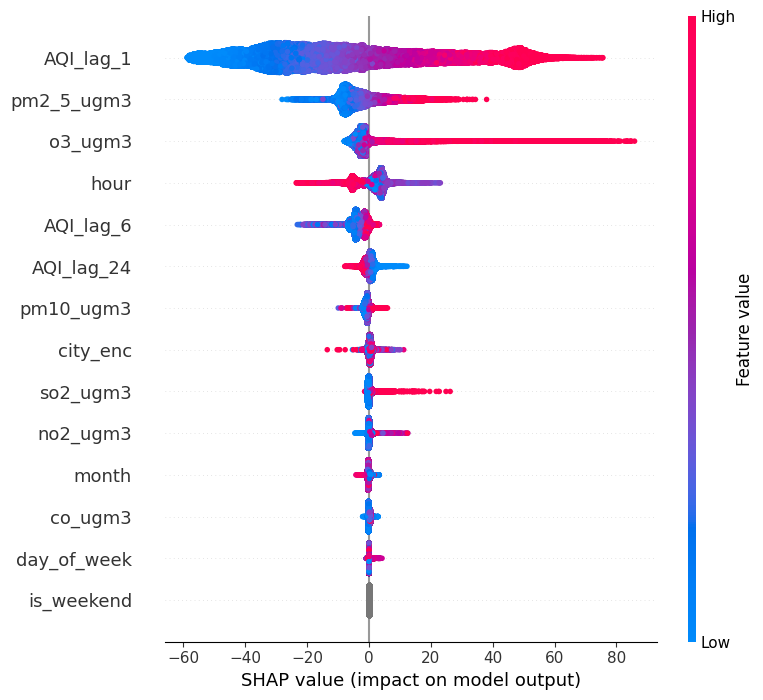

In [22]:
horizon_plot = "6h"
shap.summary_plot(
    shap_values_dict[horizon_plot],
    X_test,
    feature_names=FEATURES,
    max_display=14,
    show=True
)

### 5c. Per-City Dominant Pollutant Table

In [23]:
print("=" * 60)
print("Dominant pollutant driver per city at each horizon")
print("=" * 60)

dominant_df = pd.DataFrame()
for horizon in HORIZONS:
    profile = city_shap_profiles[horizon][POLLUTANT_COLS]
    dominant_df[f"+{horizon}"] = profile.idxmax(axis=1)

display(dominant_df)

Dominant pollutant driver per city at each horizon


,+6h,+12h,+24h
city,,,
raipur,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3
ranchi,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3
shillong,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3
shimla,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3
thiruvananthapuram,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3
visakhapatnam,pm2_5_ugm3,pm2_5_ugm3,pm2_5_ugm3


---
# Part B — NMF-Based Source Signature Analysis

Non-negative Matrix Factorisation decomposes the pollutant concentration matrix **V** (N × 6) into:  
- **W** (N × K) — how strongly each observation is influenced by each source  
- **H** (K × 6) — the chemical fingerprint (spectral profile) of each source

We use a separate working copy of the full dataset (before the modelling subset) so that we learn source profiles from all available data.

## 6. Prepare NMF Input Matrix

In [24]:
# Use the full cleaned dataset (including rows dropped for lag/target NaNs)
nmf_raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
nmf_raw = nmf_raw.sort_values(["city", "datetime"]).reset_index(drop=True)

nmf_df = nmf_raw[["city", "datetime"] + POLLUTANT_COLS].dropna().reset_index(drop=True)
print(f"NMF working dataframe: {nmf_df.shape}")
nmf_df[POLLUTANT_COLS].describe().round(2)

NMF working dataframe: (833756, 8)


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
count,833756.00,833756.00,833756.0,833756.00,833756.00,833756.00
mean,34.54,54.00,444.9,15.99,13.39,80.18
std,29.64,54.21,377.0,19.90,18.92,44.76
min,1.90,2.30,96.0,0.00,0.20,0.00
25%,14.70,21.50,235.0,3.70,2.80,47.00
50%,25.90,39.00,333.0,9.00,6.90,73.00
75%,44.20,66.40,508.0,19.90,15.80,108.00
max,183.50,420.00,2903.0,122.10,134.20,228.00


In [25]:
# ── Scale to [0, 1] so each pollutant is on a comparable scale ─────────────────
scaler = MinMaxScaler()
V = scaler.fit_transform(nmf_df[POLLUTANT_COLS])

# Save scaler — needed to preprocess live readings at inference time
joblib.dump(scaler, os.path.join(MODELS_DIR, "nmf_scaler.pkl"))
print(f"V matrix shape: {V.shape}")
print(f"V range: [{V.min():.3f}, {V.max():.3f}]")

V matrix shape: (833756, 6)
V range: [0.000, 1.000]


## 7. Elbow Plot — Choose Optimal K

  K=2  reconstruction error = 150.7176
  K=3  reconstruction error = 112.9189
  K=4  reconstruction error = 75.4077
  K=5  reconstruction error = 47.1532
  K=6  reconstruction error = 0.8329


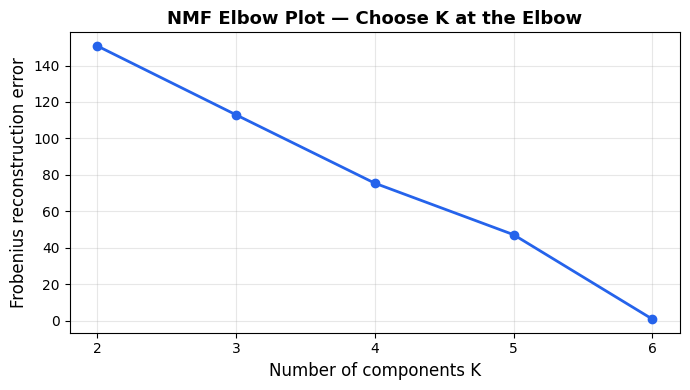

In [26]:
K_range = range(2, 7)   # K = 2 … 6 (n_features=6, so max K=6)
errors  = []

for k in K_range:
    # Use 'nndsvd' instead of 'nndsvda' for better compatibility with constraint
    init_method = 'nndsvd' if k <= 6 else 'random'
    
    nmf_k = NMF(
        n_components=k,
        init=init_method,
        random_state=RANDOM_SEED,
        max_iter=500
    )
    W_k = nmf_k.fit_transform(V)
    recon_err = nmf_k.reconstruction_err_
    errors.append(recon_err)
    print(f"  K={k}  reconstruction error = {recon_err:.4f}")

# ── Elbow plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), errors, marker="o", lw=2, color="#2563EB")
ax.set_xlabel("Number of components K", fontsize=12)
ax.set_ylabel("Frobenius reconstruction error", fontsize=12)
ax.set_title("NMF Elbow Plot — Choose K at the Elbow", fontsize=13, fontweight="bold")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "nmf_elbow.png"), dpi=150, bbox_inches="tight")
plt.show()


In [27]:
# ── Pick K — inspect the elbow plot above and set here ────────────────────────
# Common result for urban Indian pollution datasets is K=3 or K=4.
# Change this value if your elbow falls elsewhere.
K_CHOSEN = 3
print(f"Selected K = {K_CHOSEN}")

Selected K = 3


## 8. Train Final NMF Model

In [28]:
nmf_final = NMF(
    n_components=K_CHOSEN,
    init="nndsvda",
    random_state=RANDOM_SEED,
    max_iter=1000,
    tol=1e-5
)

W = nmf_final.fit_transform(V)   # (N, K) — source contributions per observation
H = nmf_final.components_        # (K, 6) — source fingerprints

print(f"W shape: {W.shape}")
print(f"H shape: {H.shape}")
print(f"Final reconstruction error: {nmf_final.reconstruction_err_:.4f}")

# Save model
joblib.dump(nmf_final, os.path.join(MODELS_DIR, "nmf_model.pkl"))
print("NMF model saved → models/nmf_model.pkl")

W shape: (833756, 3)
H shape: (3, 6)
Final reconstruction error: 112.9208
NMF model saved → models/nmf_model.pkl


## 9. Inspect H Matrix — Source Fingerprints

Each row of H is a source profile. The **dominant pollutants** in each row tell us what type of emission source it represents.

H matrix (source fingerprints) — raw weights:


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
Component_1,1.1465,0.0251,0.7436,0.0000,2.3031,28.7097
Component_2,3.8198,0.2471,8.8273,13.3396,9.3735,0.0000
Component_3,10.7444,9.8993,2.8523,0.5741,0.0000,0.1361



H matrix — row-normalised (relative pollutant share per source):


,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
Component_1,0.035,0.001,0.023,0.000,0.070,0.872
Component_2,0.107,0.007,0.248,0.375,0.263,0.000
Component_3,0.444,0.409,0.118,0.024,0.000,0.006


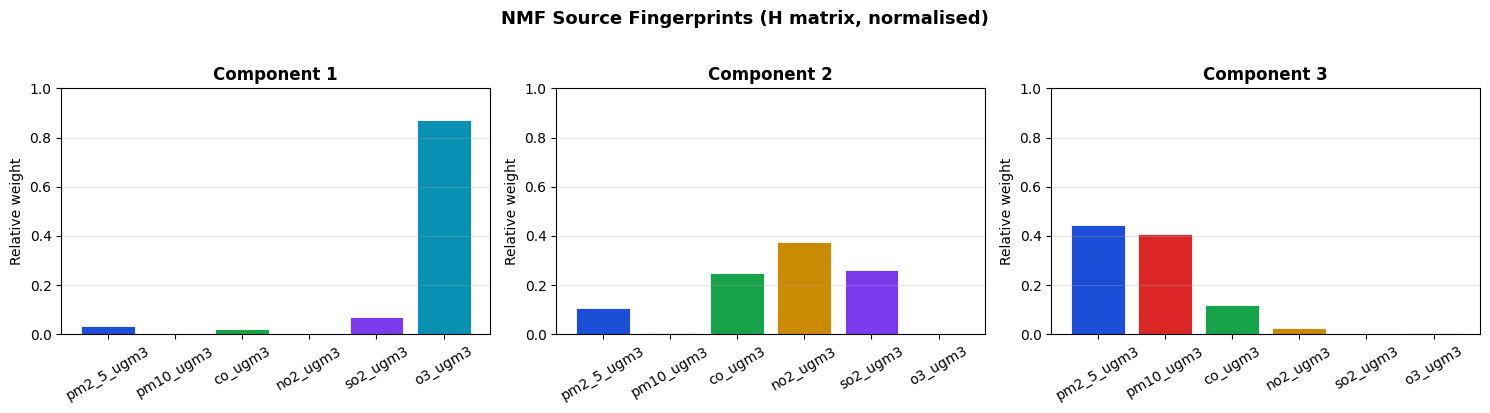

In [29]:
H_df = pd.DataFrame(
    H,
    columns=POLLUTANT_COLS,
    index=[f"Component_{i+1}" for i in range(K_CHOSEN)]
)

print("H matrix (source fingerprints) — raw weights:")
display(H_df.round(4))

# Normalise rows to show relative contribution of each pollutant within a source
H_norm = H_df.div(H_df.sum(axis=1), axis=0)
print("\nH matrix — row-normalised (relative pollutant share per source):")
display(H_norm.round(3))

# Bar chart for each component
fig, axes = plt.subplots(1, K_CHOSEN, figsize=(5 * K_CHOSEN, 4), sharey=False)
if K_CHOSEN == 1:
    axes = [axes]
colours = ["#1D4ED8", "#DC2626", "#16A34A", "#CA8A04", "#7C3AED", "#0891B2"]
for idx, ax in enumerate(axes):
    vals = H_norm.iloc[idx]
    ax.bar(POLLUTANT_COLS, vals, color=colours[:len(POLLUTANT_COLS)], edgecolor="white", linewidth=0.6)
    ax.set_title(f"Component {idx+1}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Relative weight")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("NMF Source Fingerprints (H matrix, normalised)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "nmf_source_fingerprints.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 10. ✏️ Manual Source Labelling

**Read the H matrix bar charts above and assign a human-readable label to each component here.**

Typical patterns for Indian urban environments:

| Pattern | Likely source |
|---|---|
| High PM2.5 + CO, moderate NO2 | **Traffic / vehicular combustion** |
| High SO2 + PM10, moderate NO2 | **Industrial / coal combustion** |
| High O3, low primary pollutants | **Photochemical / secondary aerosol** |
| High PM10 + low SO2 + low CO | **Road dust / construction** |
| Broad elevation of all species | **Biomass burning / crop residue** |

Edit the dictionary below to match your components:

In [30]:
# ── EDIT THIS DICTIONARY after inspecting the bar charts above ─────────────────
SOURCE_LABELS = {
    "Component_1": "Traffic / Vehicular",
    "Component_2": "Industrial / Coal",
    "Component_3": "Photochemical / Ozone",
    # Add more rows if K_CHOSEN > 3
}

# Validate
for i in range(1, K_CHOSEN + 1):
    key = f"Component_{i}"
    assert key in SOURCE_LABELS, f"Missing label for {key}!"

print("Source labels confirmed:")
for k, v in SOURCE_LABELS.items():
    print(f"  {k} → {v}")

Source labels confirmed:
  Component_1 → Traffic / Vehicular
  Component_2 → Industrial / Coal
  Component_3 → Photochemical / Ozone


## 11. Attach W to Dataframe & Aggregate City Profiles

In [31]:
# Attach W columns back to the working dataframe
w_cols = [f"Source_{i+1}" for i in range(K_CHOSEN)]
W_df = pd.DataFrame(W, columns=w_cols)

nmf_df = pd.concat(
    [nmf_df.reset_index(drop=True), W_df],
    axis=1
)

# ── Rename W columns to human-readable source labels ──────────────────────────
label_rename = {
    f"Source_{i+1}": SOURCE_LABELS[f"Component_{i+1}"]
    for i in range(K_CHOSEN)
}
nmf_df = nmf_df.rename(columns=label_rename)
source_label_cols = list(label_rename.values())

print("Columns in nmf_df:", list(nmf_df.columns))
nmf_df[["city"] + source_label_cols].head(5)

Columns in nmf_df: ['city', 'datetime', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'Traffic / Vehicular', 'Industrial / Coal', 'Photochemical / Ozone']


,city,Traffic / Vehicular,Industrial / Coal,Photochemical / Ozone
0,agartala,0.004653,0.007645,0.003479
1,agartala,0.004844,0.006587,0.004135
2,agartala,0.005036,0.005518,0.004652
3,agartala,0.004742,0.005186,0.005318
4,agartala,0.004438,0.005125,0.005610


In [32]:
# ── City-level source profiles (mean W per city) ───────────────────────────────
city_source_profile = nmf_df.groupby("city")[source_label_cols].mean()

# Normalise rows to percentages
city_source_pct = city_source_profile.div(city_source_profile.sum(axis=1), axis=0) * 100

print("City-level source contribution (% of total):")
display(city_source_pct.round(1))

# Save
out_path = os.path.join(ANALYSIS_DIR, "nmf_city_source_profiles.csv")
city_source_pct.to_csv(out_path)
print(f"Saved → {out_path}")

City-level source contribution (% of total):


,Traffic / Vehicular,Industrial / Coal,Photochemical / Ozone
city,,,
agartala,32.3,26.4,41.3
ahmedabad,34.1,31.3,34.6
aizawl,51.8,14.5,33.7
bengaluru,42.4,32.6,25.0
bhopal,48.6,11.2,40.2
bhubaneswar,38.8,19.5,41.7
chandigarh,32.9,31.1,36.0
chennai,48.1,23.9,28.1
dehradun,43.4,24.4,32.2


Saved → analysis/nmf_city_source_profiles.csv


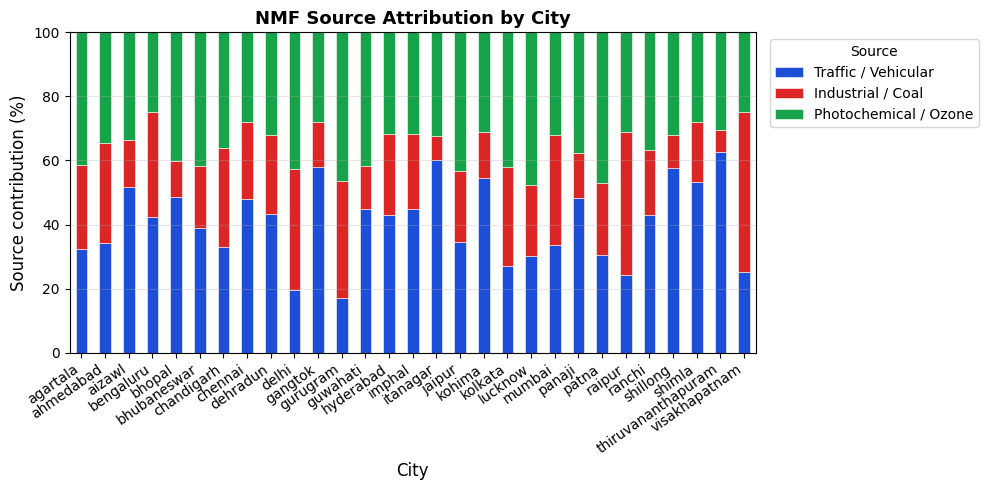

In [33]:
# ── Stacked bar chart — city source profiles ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

palette = ["#1D4ED8", "#DC2626", "#16A34A", "#CA8A04", "#7C3AED"]
city_source_pct.plot(
    kind="bar", stacked=True,
    color=palette[:K_CHOSEN],
    edgecolor="white", linewidth=0.4,
    ax=ax
)
ax.set_ylabel("Source contribution (%)", fontsize=12)
ax.set_xlabel("City", fontsize=12)
ax.set_title("NMF Source Attribution by City", fontsize=13, fontweight="bold")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "nmf_city_source_attribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
# Part C — Real-Time Inference Function

This is the **single entry-point** the Streamlit dashboard calls. It accepts:
- `city_name` — the city the user selected
- `live_reading` — a dict with the six pollutant values (typically from OpenAQ API)
- `horizon` — forecast window (`"6h"`, `"12h"`, or `"24h"`; default `"6h"`)

And returns a dict with three keys:
- `prime_pollutant` — which pollutant dominates AQI right now for this city at this horizon  
- `source_split` — NMF-derived percentage contribution of each source  
- `dominant_source` — the single largest source label

## 12. Load All Artefacts for Inference

In [34]:
# ── CHECK: Did you run cell 3? ────────────────────────────────────────────────
if 'shap_explainers' not in locals():
    print("❌ ERROR: Cell 3 has NOT been run yet!")
    print("   You MUST run cells 1 → 3 in order first.")
    print("   Please run Cell 3 (Compute SHAP Values) to create the explainers.")
    raise RuntimeError("Cell 3 must be run before Cell 12")

# These are already in memory from the cells above, but we reload from disk
# to simulate the dashboard startup path exactly.

inf_explainers = {}
all_none = True
for h in HORIZONS:
    explainer_path = os.path.join(MODELS_DIR, f"shap_explainer_{h}.pkl")
    if os.path.exists(explainer_path):
        inf_explainers[h] = joblib.load(explainer_path)
        print(f"[{h}] Loaded explainer from disk ✓")
        all_none = False
    else:
        # Use in-memory explainer if available
        if h in shap_explainers and shap_explainers[h] is not None:
            inf_explainers[h] = shap_explainers[h]
            # Save it to disk now so it's available later
            joblib.dump(shap_explainers[h], explainer_path)
            print(f"[{h}] Using in-memory explainer and saving to disk ✓")
            all_none = False
        else:
            print(f"[{h}] WARNING: No explainer available (fallback was used)")
            inf_explainers[h] = None

if all_none:
    print("\n" + "="*70)
    print("⚠️  ALL EXPLAINERS ARE NONE — This means Cell 3 used the fallback")
    print("="*70)
    print("This happens when the XGBoost models are not compatible with SHAP.")
    print("\nTO FIX:")
    print("1. Check that the model files exist in:", MODELS_DIR)
    print("2. Make sure the models were trained with XGBoost (not LightGBM)")
    print("3. Re-run Cell 3 and check for error messages")
    print("="*70)

inf_nmf    = joblib.load(os.path.join(MODELS_DIR, "nmf_model.pkl"))
inf_scaler = joblib.load(os.path.join(MODELS_DIR, "nmf_scaler.pkl"))

inf_shap_profiles = {
    h: pd.read_csv(os.path.join(ANALYSIS_DIR, f"shap_city_profiles_{h}.csv"), index_col=0)
    for h in HORIZONS
}

inf_city_sources = pd.read_csv(
    os.path.join(ANALYSIS_DIR, "nmf_city_source_profiles.csv"), index_col=0
)

# K and label map (must match training cell)
inf_source_labels = list(SOURCE_LABELS.values())  # e.g. ["Traffic", "Industrial", "Photochemical"]

print("\nAll inference artefacts loaded.")
print("Source labels:", inf_source_labels)


[6h] Loaded explainer from disk ✓
[12h] Loaded explainer from disk ✓
[24h] Loaded explainer from disk ✓

All inference artefacts loaded.
Source labels: ['Traffic / Vehicular', 'Industrial / Coal', 'Photochemical / Ozone']


## 13. `explain_city_reading()` — The Dashboard Inference Function

In [35]:
def explain_city_reading(
    city_name: str,
    live_reading: dict,
    horizon: str = "6h",
) -> dict:
    """
    Explain a live pollutant reading for a given city.

    Parameters
    ----------
    city_name : str
        Must match a city in the training data (case-sensitive).
    live_reading : dict
        Keys: pm2_5_ugm3, pm10_ugm3, co_ugm3, no2_ugm3, so2_ugm3, o3_ugm3
        Values: float concentrations from OpenAQ or any real-time source.
    horizon : str
        One of '6h', '12h', '24h'.

    Returns
    -------
    dict with keys:
        prime_pollutant   : str  — pollutant with highest mean |SHAP| for this city/horizon
        source_split      : dict — source label → % contribution (from NMF city profile)
        dominant_source   : str  — source with largest share
        live_shap_values  : dict — feature → SHAP value for THIS specific reading (or None if explainer unavailable)
        live_source_pct   : dict — source label → % contribution for THIS specific reading
    """
    assert horizon in inf_explainers, f"Unknown horizon '{horizon}'. Choose from {list(inf_explainers.keys())}"

    # ── 1. Prime pollutant: city-level mean SHAP profile ──────────────────────
    shap_profile = inf_shap_profiles[horizon]
    if city_name not in shap_profile.index:
        raise ValueError(f"City '{city_name}' not found in SHAP profiles. "
                         f"Available: {list(shap_profile.index)}")

    # Among POLLUTANT_COLS only — we want the environmental driver, not lag features
    city_pollutant_shap = shap_profile.loc[city_name, POLLUTANT_COLS]
    prime_pollutant = city_pollutant_shap.idxmax()

    # ── 2. Source split: city-level NMF profile (pre-aggregated) ──────────────
    if city_name not in inf_city_sources.index:
        raise ValueError(f"City '{city_name}' not found in NMF source profiles.")

    city_src = inf_city_sources.loc[city_name]  # already in %
    source_split   = city_src.to_dict()
    dominant_source = city_src.idxmax()

    # ── 3. Live SHAP explanation for THIS single reading ──────────────────────
    live_shap_values = None
    explainer = inf_explainers[horizon]
    
    if explainer is not None:
        # We need a full feature vector matching FEATURES order.
        # Non-pollutant features (lags, time, city_enc) are not available in a live
        # OpenAQ reading, so we fill them with the city mean from the training set.
        # This is an approximation — the pollutant SHAP values are the key output.
        city_rows = df[df["city"] == city_name]
        city_means = city_rows[FEATURES].mean().to_dict()

        live_vec = city_means.copy()
        for col in POLLUTANT_COLS:
            if col in live_reading:
                live_vec[col] = live_reading[col]

        live_row = pd.DataFrame([live_vec])[FEATURES]  # ensure column order
        try:
            live_sv   = explainer.shap_values(live_row, check_additivity=False)[0]
            live_shap_values = dict(zip(FEATURES, live_sv))
        except Exception as e:
            print(f"Warning: Could not compute live SHAP values: {str(e)[:50]}")
            live_shap_values = None
    else:
        print("Warning: SHAP explainer not available (fallback initialization was used)")
        live_shap_values = None

    # ── 4. Live NMF source split for THIS reading ─────────────────────────────
    raw_vec   = np.array([[live_reading.get(c, 0.0) for c in POLLUTANT_COLS]])
    scaled_vec = inf_scaler.transform(raw_vec)
    scaled_vec = np.clip(scaled_vec, 0, None)  # NMF requires non-negative
    w_live    = inf_nmf.transform(scaled_vec)[0]  # (K,)

    w_total = w_live.sum() or 1.0
    live_source_pct = {
        label: round(float(w_live[i] / w_total * 100), 1)
        for i, label in enumerate(inf_source_labels)
    }

    return {
        "prime_pollutant":  prime_pollutant,
        "source_split":     source_split,
        "dominant_source":  dominant_source,
        "live_shap_values": live_shap_values,
        "live_source_pct":  live_source_pct,
    }


## 14. Demo Call — Mocked Live Reading

Simulates a user selecting **Delhi** in the dashboard while OpenAQ returns a mid-day reading.

In [36]:
# ── Mock OpenAQ reading for a city at a hypothetical bad-air afternoon ────────
# Use a city that's actually in the SHAP profiles
available_cities = inf_shap_profiles["6h"].index.tolist()
DEMO_CITY = available_cities[0] if available_cities else df["city"].iloc[0]

MOCK_READING = {
    "pm2_5_ugm3": 145.2,
    "pm10_ugm3":  210.0,
    "co_ugm3":      1.8,
    "no2_ugm3":    58.4,
    "so2_ugm3":    12.1,
    "o3_ugm3":     34.7,
}

print(f"Demo city : {DEMO_CITY}")
print(f"Available cities: {available_cities}")
print(f"Live reading: {MOCK_READING}")
print("-" * 55)

result = explain_city_reading(
    city_name=DEMO_CITY,
    live_reading=MOCK_READING,
    horizon="6h"
)

print(f"\n🏭  Prime pollutant driving AQI (+6h) : {result['prime_pollutant']}")
print(f"💨  Dominant emission source           : {result['dominant_source']}")
print(f"\n📊  City-level source split (historical avg)")
for src, pct in result["source_split"].items():
    print(f"    {src:<30} {pct:5.1f}%")

print(f"\n🔬  Live source split (this reading)")
for src, pct in result["live_source_pct"].items():
    print(f"    {src:<30} {pct:5.1f}%")

if result["live_shap_values"] is not None:
    print(f"\n📈  Top-5 SHAP drivers for this reading:")
    sorted_shap = sorted(result["live_shap_values"].items(), key=lambda x: abs(x[1]), reverse=True)
    for feat, sv in sorted_shap[:5]:
        direction = "+" if sv >= 0 else "-"
        print(f"    {feat:<25}  {direction}{abs(sv):.3f}")
else:
    print(f"\n⚠️  Live SHAP values not available (explainer not loaded)")


Demo city : raipur
Available cities: ['raipur', 'ranchi', 'shillong', 'shimla', 'thiruvananthapuram', 'visakhapatnam']
Live reading: {'pm2_5_ugm3': 145.2, 'pm10_ugm3': 210.0, 'co_ugm3': 1.8, 'no2_ugm3': 58.4, 'so2_ugm3': 12.1, 'o3_ugm3': 34.7}
-------------------------------------------------------

🏭  Prime pollutant driving AQI (+6h) : pm2_5_ugm3
💨  Dominant emission source           : Industrial / Coal

📊  City-level source split (historical avg)
    Traffic / Vehicular             24.3%
    Industrial / Coal               44.5%
    Photochemical / Ozone           31.1%

🔬  Live source split (this reading)
    Traffic / Vehicular              6.1%
    Industrial / Coal               21.6%
    Photochemical / Ozone           72.3%

📈  Top-5 SHAP drivers for this reading:
    pm2_5_ugm3                 +27.385
    AQI_lag_1                  +25.762
    pm10_ugm3                  +4.687
    o3_ugm3                    -3.955
    hour                       +2.499


---
# Summary — All Output Files

| File | Location | Used by |
|---|---|---|
| `shap_city_profiles_6h.csv` | `analysis/` | Dashboard city-level prime pollutant card |
| `shap_city_profiles_12h.csv` | `analysis/` | Dashboard (12h tab) |
| `shap_city_profiles_24h.csv` | `analysis/` | Dashboard (24h tab) |
| `nmf_city_source_profiles.csv` | `analysis/` | Dashboard source attribution chart |
| `shap_explainer_6h.pkl` | `models/` | Live single-prediction SHAP |
| `shap_explainer_12h.pkl` | `models/` | Live single-prediction SHAP |
| `shap_explainer_24h.pkl` | `models/` | Live single-prediction SHAP |
| `nmf_model.pkl` | `models/` | Live NMF source split |
| `nmf_scaler.pkl` | `models/` | Pre-processes live reading before NMF |